In [13]:
import sys, os
sys.path.insert(0, '/workspace/PCFG')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from copy import deepcopy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

HISTORIES_DIR = '/workspace/PCFG/results/histories'
MODELS_DIR    = '/workspace/PCFG/results/models'
PRETRAIN_DIR  = '/workspace/PCFG'


Device: cuda


In [14]:
import glob

history_files = sorted(glob.glob(f'{HISTORIES_DIR}/*_history.pth'))
print("Found history files:")
for f in history_files:
    print(' ', os.path.basename(f))

histories = {}
for f in history_files:
    key = os.path.basename(f).replace('_history.pth', '')
    histories[key] = torch.load(f, map_location='cpu')

# Quick peek at structure
k0 = list(histories.keys())[0]
h0 = histories[k0]
print(f"\nHistory keys for '{k0}':", list(h0.keys()))
print(f"Val splits: {list(h0['val'].keys())}")
print(f"Steps logged: {h0['steps']}")


Found history files:
  finetune_corr_0.00_conc_0.10_history.pth
  finetune_corr_0.00_conc_0.30_history.pth
  finetune_corr_0.00_conc_0.50_history.pth
  finetune_corr_0.00_conc_0.70_history.pth
  finetune_corr_0.00_conc_0.90_history.pth
  finetune_corr_0.00_conc_1.00_history.pth
  finetune_corr_0.25_conc_0.10_history.pth
  finetune_corr_0.25_conc_0.30_history.pth
  finetune_corr_0.25_conc_0.50_history.pth
  finetune_corr_0.25_conc_0.70_history.pth
  finetune_corr_0.25_conc_0.90_history.pth
  finetune_corr_0.25_conc_1.00_history.pth
  finetune_corr_0.50_conc_0.10_history.pth
  finetune_corr_0.50_conc_0.30_history.pth
  finetune_corr_0.50_conc_0.50_history.pth
  finetune_corr_0.50_conc_0.70_history.pth
  finetune_corr_0.50_conc_0.90_history.pth
  finetune_corr_0.50_conc_1.00_history.pth
  finetune_corr_0.75_conc_0.10_history.pth
  finetune_corr_0.75_conc_0.30_history.pth
  finetune_corr_0.75_conc_0.50_history.pth
  finetune_corr_0.75_conc_0.70_history.pth
  finetune_corr_0.75_conc_0.90_hi

In [15]:
key

'reverse_corr_1.00_conc_1.00'

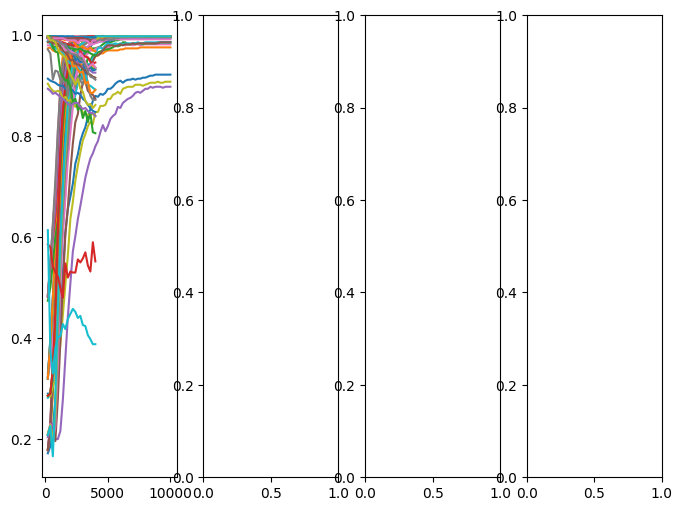

In [16]:
fig,ax = plt.subplots(1, 4, figsize=(8, 6))
for i in range(len(histories)):
    key = list(histories.keys())[i]
    h = histories[key]
    steps = h['steps']
    val_acc = h['val']['count_a_corr']['answer_acc']
    ax[0].plot(steps, val_acc, label=key)
    # ax[i].set_title(key)
    # ax[i].set_xlabel('Steps')
    # ax[i].set_ylabel('Val Acc')
    # ax[i].legend()

In [17]:
rows = []
for key, hist in sorted(histories.items()):
    steps = hist['steps']
    row = {'run': key, 'final_step': steps[-1],
           'train_loss': hist['train_loss'][-1],
           'train_acc':  hist['train_answer_acc'][-1]}
    for split in VAL_SPLITS:
        if split in hist['val']:
            row[f'{split}_loss'] = hist['val'][split]['loss'][-1]
            row[f'{split}_acc']  = hist['val'][split]['answer_acc'][-1]
    rows.append(row)

df = pd.DataFrame(rows).set_index('run')
pd.set_option('display.float_format', '{:.4f}'.format)
display(df.T)


run,finetune_corr_0.00_conc_0.10,finetune_corr_0.00_conc_0.30,finetune_corr_0.00_conc_0.50,finetune_corr_0.00_conc_0.70,finetune_corr_0.00_conc_0.90,finetune_corr_0.00_conc_1.00,finetune_corr_0.25_conc_0.10,finetune_corr_0.25_conc_0.30,finetune_corr_0.25_conc_0.50,finetune_corr_0.25_conc_0.70,...,reverse_corr_0.75_conc_0.50,reverse_corr_0.75_conc_0.70,reverse_corr_0.75_conc_0.90,reverse_corr_0.75_conc_1.00,reverse_corr_1.00_conc_0.10,reverse_corr_1.00_conc_0.30,reverse_corr_1.00_conc_0.50,reverse_corr_1.00_conc_0.70,reverse_corr_1.00_conc_0.90,reverse_corr_1.00_conc_1.00
final_step,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,...,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000
train_loss,0.4363,0.4347,0.4331,0.4336,0.4312,0.4282,0.4400,0.4398,0.4381,0.4341,...,0.4345,0.4334,0.4322,0.4339,0.4251,0.4266,0.4262,0.4251,0.4245,0.4232
train_acc,0.9792,0.9375,0.8854,0.9062,0.9479,0.9896,0.9792,0.9479,0.9792,0.9688,...,0.9896,0.9688,0.9792,0.9688,0.9375,0.9583,0.9271,0.9479,0.9375,0.9688
count_a_corr_loss,0.4063,0.1016,0.0538,0.0383,0.0305,0.0284,0.0953,0.0310,0.0217,0.0178,...,0.2117,0.2671,0.5180,1.5696,0.5750,0.2779,0.2200,0.2504,0.4040,2.2916
count_a_corr_acc,0.9220,0.9760,0.9960,0.9980,0.9980,0.9980,0.9820,0.9980,0.9980,0.9980,...,0.9320,0.8920,0.8060,0.5520,0.8400,0.9160,0.9360,0.9120,0.8620,0.3880
count_a_uncorr_loss,0.3790,0.1007,0.0480,0.0297,0.0211,0.0186,0.1307,0.0395,0.0232,0.0171,...,0.2666,0.3458,0.6775,1.9108,2.1235,1.8889,1.8250,1.9155,2.1399,3.6702
count_a_uncorr_acc,0.9260,0.9800,0.9900,0.9900,0.9920,0.9940,0.9740,0.9920,0.9940,0.9940,...,0.9100,0.8620,0.7140,0.4280,0.5260,0.5420,0.5500,0.5280,0.4840,0.2760
count_b_loss,0.0012,0.0032,0.0093,0.0324,0.1313,0.6121,0.0002,0.0002,0.0002,0.0003,...,0.0012,0.0014,0.0014,0.0017,3.6363,3.4043,3.3049,3.1685,3.1028,3.1870
count_b_acc,1.0000,1.0000,0.9960,0.9860,0.9480,0.8200,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,1.0000,0.4680,0.4860,0.4920,0.5000,0.4980,0.5040
all_other_avg_loss,0.0328,0.0345,0.0366,0.0405,0.0531,0.1249,0.0280,0.0287,0.0298,0.0324,...,0.0301,0.0306,0.0320,0.0329,0.9309,0.9340,0.9189,0.9207,0.9231,0.9212


In [18]:
from mingpt import GPT, GPTConfig
from pcfg_gen import CharTokenizer

tokenizer = CharTokenizer()
from config import CFG
mcfg = CFG['model']
gpt_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=mcfg['block_size'],
    n_layer=mcfg['n_layer'],
    n_head=mcfg['n_head'],
    n_embd=mcfg['n_embd'],
    embd_pdrop=0.0, resid_pdrop=0.0, attn_pdrop=0.0,
)

def load_state(path):
    ck = torch.load(path, map_location='cpu')
    return ck['model_state_dict']

# Load all available model pairs
model_pairs = {}
for corr in ['0.00', '1.00']:
    for conc in ['0.90', '1.00']:
        pretrain_path  = f'{PRETRAIN_DIR}/pretrain_corr_{corr}.pth'
        finetune_path  = f'{MODELS_DIR}/finetune_corr_{corr}_conc_{conc}.pth'
        if os.path.exists(pretrain_path) and os.path.exists(finetune_path):
            model_pairs[f'corr_{corr}_conc_{conc}'] = {
                'pretrain': load_state(pretrain_path),
                'finetune': load_state(finetune_path),
            }
        reverse_path = f'{MODELS_DIR}/reverse_corr_{corr}_conc_{conc}.pth'
        if os.path.exists(reverse_path):
            model_pairs[f'corr_{corr}_conc_{conc}']['reverse'] = load_state(reverse_path)



print("Loaded model pairs:", list(model_pairs.keys()))
for k, v in model_pairs.items():
    print(f"  {k}: stages = {list(v.keys())}")


Tokenizer vocabulary size: 267
Loaded model pairs: ['corr_0.00_conc_0.90', 'corr_0.00_conc_1.00', 'corr_1.00_conc_0.90', 'corr_1.00_conc_1.00']
  corr_0.00_conc_0.90: stages = ['pretrain', 'finetune', 'reverse']
  corr_0.00_conc_1.00: stages = ['pretrain', 'finetune', 'reverse']
  corr_1.00_conc_0.90: stages = ['pretrain', 'finetune', 'reverse']
  corr_1.00_conc_1.00: stages = ['pretrain', 'finetune', 'reverse']


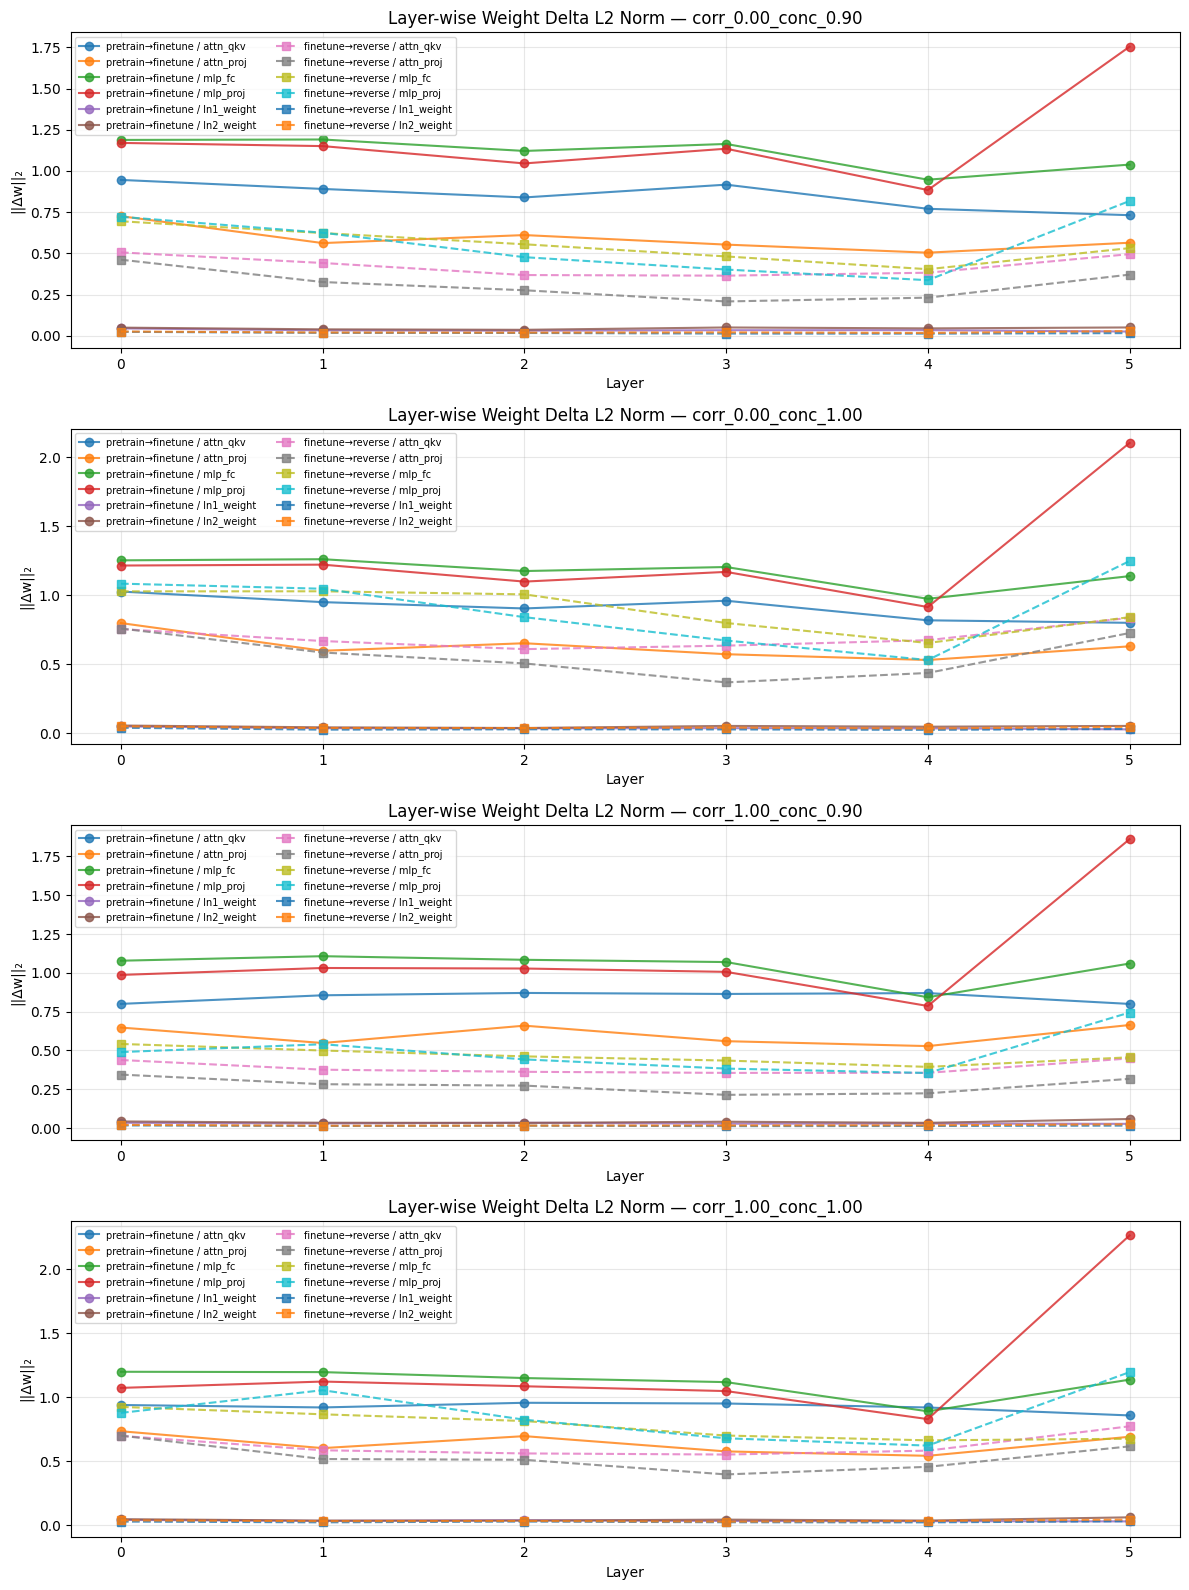

In [19]:
N_LAYERS = mcfg['n_layer']

WEIGHT_KEYS = {
    'attn_qkv':    lambda l: f'transformer.h.{l}.attn.c_attn.weight',
    'attn_proj':   lambda l: f'transformer.h.{l}.attn.c_proj.weight',
    'mlp_fc':      lambda l: f'transformer.h.{l}.mlp.c_fc.weight',
    'mlp_proj':    lambda l: f'transformer.h.{l}.mlp.c_proj.weight',
    'ln1_weight':  lambda l: f'transformer.h.{l}.ln_1.weight',
    'ln2_weight':  lambda l: f'transformer.h.{l}.ln_2.weight',
}

def compute_layer_deltas(state_a, state_b):
    """Returns dict of component -> list of L2 norms per layer."""
    deltas = {k: [] for k in WEIGHT_KEYS}
    for layer_idx in range(N_LAYERS):
        for comp, key_fn in WEIGHT_KEYS.items():
            key = key_fn(layer_idx)
            delta = (state_b[key] - state_a[key]).float()
            deltas[comp].append(delta.norm().item())
    return deltas

fig, axes = plt.subplots(len(model_pairs), 1, figsize=(12, 4*len(model_pairs)))
if len(model_pairs) == 1: axes = [axes]

for ax, (pair_name, stages) in zip(axes, sorted(model_pairs.items())):
    comparisons = []
    if 'pretrain' in stages and 'finetune' in stages:
        comparisons.append(('pretrain→finetune', stages['pretrain'], stages['finetune'], '-o'))
    if 'finetune' in stages and 'reverse' in stages:
        comparisons.append(('finetune→reverse', stages['finetune'], stages['reverse'], '--s'))

    for label, sa, sb, fmt in comparisons:
        deltas = compute_layer_deltas(sa, sb)
        x = np.arange(N_LAYERS)
        for comp, vals in deltas.items():
            ax.plot(x, vals, fmt, label=f'{label} / {comp}', alpha=0.8)

    ax.set_title(f'Layer-wise Weight Delta L2 Norm — {pair_name}')
    ax.set_xlabel('Layer'); ax.set_ylabel('||Δw||₂')
    ax.set_xticks(range(N_LAYERS))
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/workspace/PCFG/results/layer_deltas.png', dpi=150)
plt.show()


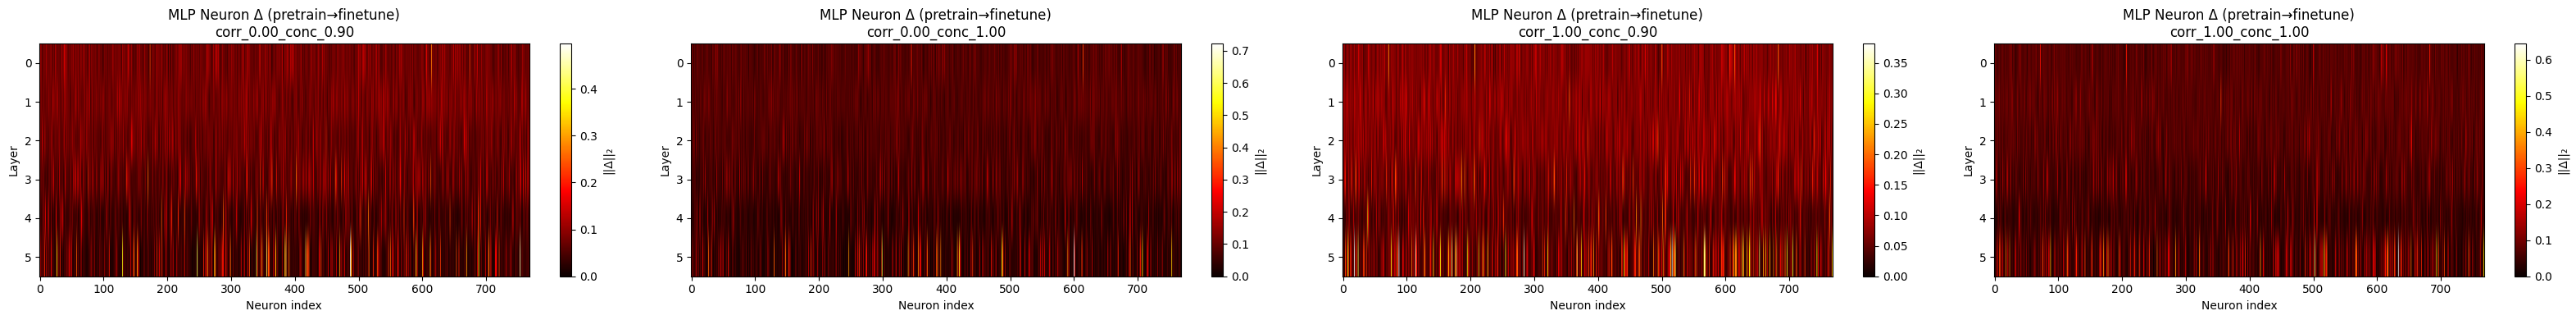

In [20]:
def compute_mlp_neuron_deltas(state_a, state_b, n_layers=6):
    """
    For each MLP neuron j in layer l, delta = ||Δc_fc[j,:]|| + ||Δc_proj[:,j]||
    Returns array of shape (n_layers, 4*n_embd).
    """
    n_neurons = 4 * mcfg['n_embd']  # 768
    out = np.zeros((n_layers, n_neurons))
    for l in range(n_layers):
        fc_key   = f'transformer.h.{l}.mlp.c_fc.weight'    # (768, 192)
        proj_key = f'transformer.h.{l}.mlp.c_proj.weight'  # (192, 768)
        d_fc   = (state_b[fc_key]   - state_a[fc_key]).float()   # (768, 192)
        d_proj = (state_b[proj_key] - state_a[proj_key]).float() # (192, 768)
        out[l] = d_fc.norm(dim=1).numpy() + d_proj.norm(dim=0).numpy()
    return out

fig, axes = plt.subplots(1, len(model_pairs), figsize=(8*len(model_pairs), 4))
if len(model_pairs) == 1: axes = [axes]

for ax, (pair_name, stages) in zip(axes, sorted(model_pairs.items())):
    sa, sb = stages['pretrain'], stages['finetune']
    neuron_deltas = compute_mlp_neuron_deltas(sa, sb)
    im = ax.imshow(neuron_deltas, aspect='auto', cmap='hot')
    ax.set_title(f'MLP Neuron Δ (pretrain→finetune)\n{pair_name}')
    ax.set_xlabel('Neuron index'); ax.set_ylabel('Layer')
    ax.set_yticks(range(N_LAYERS))
    plt.colorbar(im, ax=ax, label='||Δ||₂')

plt.tight_layout()
plt.savefig('/workspace/PCFG/results/neuron_delta_heatmap.png', dpi=150)
plt.show()



corr_0.00_conc_0.90 — top 50 neurons by Δ magnitude:
  Layer distribution: {0: 2, 3: 4, 4: 7, 5: 37}


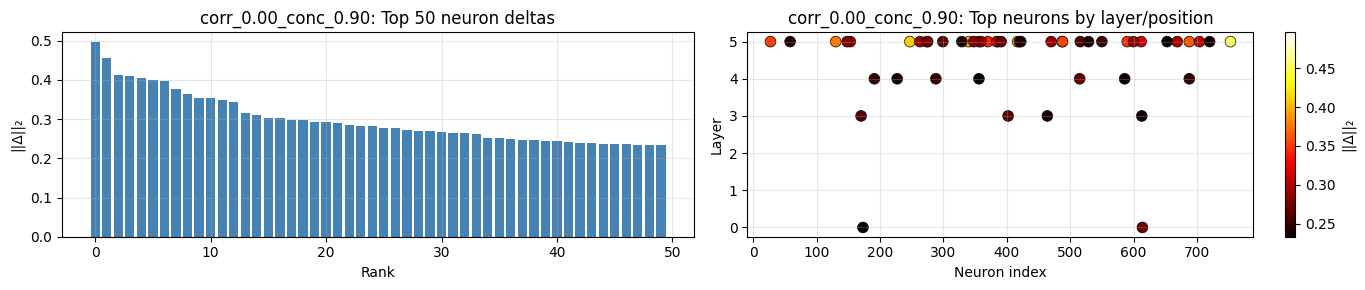


corr_0.00_conc_1.00 — top 50 neurons by Δ magnitude:
  Layer distribution: {0: 2, 3: 2, 4: 5, 5: 41}


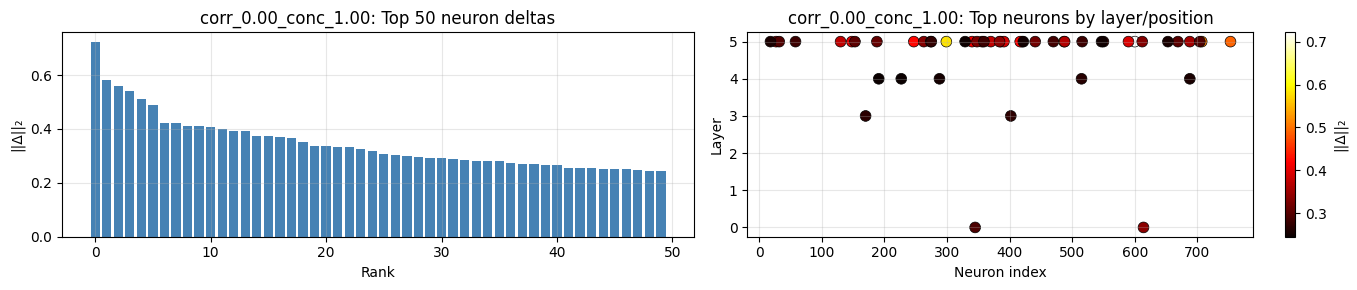


corr_1.00_conc_0.90 — top 50 neurons by Δ magnitude:
  Layer distribution: {0: 1, 3: 2, 4: 2, 5: 45}


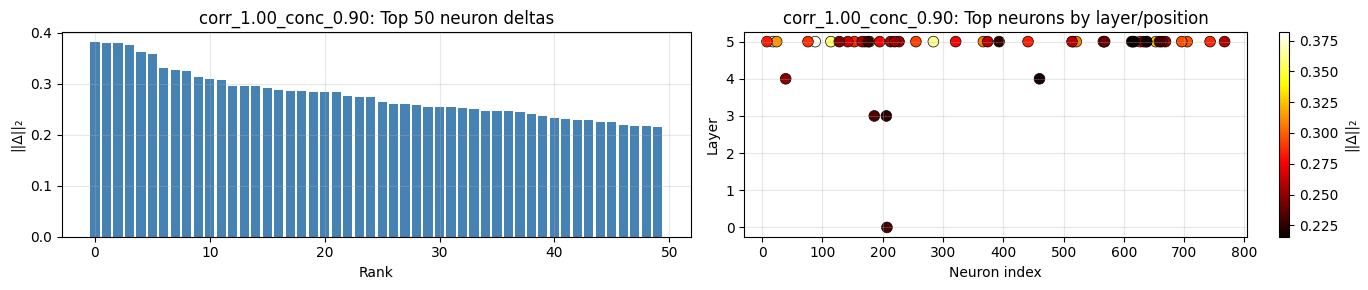


corr_1.00_conc_1.00 — top 50 neurons by Δ magnitude:
  Layer distribution: {0: 2, 1: 1, 5: 47}


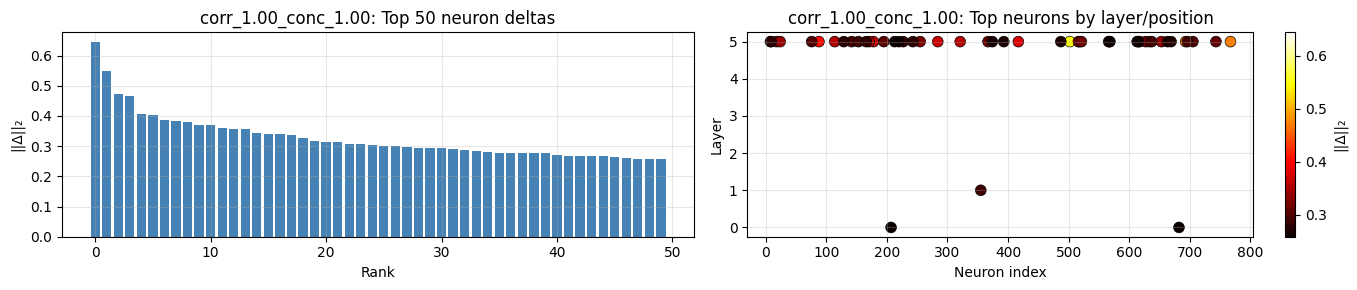

In [21]:
TOP_N = 50

for pair_name, stages in sorted(model_pairs.items()):
    sa, sb = stages['pretrain'], stages['finetune']
    nd = compute_mlp_neuron_deltas(sa, sb)   # (6, 768)
    flat = nd.flatten()
    top_idx = np.argsort(flat)[::-1][:TOP_N]
    layer_idx  = top_idx // nd.shape[1]
    neuron_idx = top_idx %  nd.shape[1]

    print(f"\n{pair_name} — top {TOP_N} neurons by Δ magnitude:")
    layer_counts = pd.Series(layer_idx).value_counts().sort_index()
    print("  Layer distribution:", layer_counts.to_dict())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3))
    ax1.bar(range(TOP_N), flat[top_idx], color='steelblue')
    ax1.set_xlabel('Rank'); ax1.set_ylabel('||Δ||₂')
    ax1.set_title(f'{pair_name}: Top {TOP_N} neuron deltas')
    ax1.grid(True, alpha=0.3)

    scatter = ax2.scatter(neuron_idx, layer_idx, c=flat[top_idx], cmap='hot', s=60, edgecolors='k', lw=0.5)
    plt.colorbar(scatter, ax=ax2, label='||Δ||₂')
    ax2.set_xlabel('Neuron index'); ax2.set_ylabel('Layer')
    ax2.set_title(f'{pair_name}: Top neurons by layer/position')
    ax2.set_yticks(range(N_LAYERS)); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/workspace/PCFG/results/top_neurons_{pair_name}.png', dpi=150)
    plt.show()


In [22]:
from config import CFG
from config_utils import build_task_registry, set_seed
from pcfg_gen import PCFGGenerator, PCFGDataset, build_pools, generate_dataset, format_example
from torch.utils.data import DataLoader
from pcfg_gen import collate_fn

set_seed(42)
pcfg = PCFGGenerator()
task_registry = build_task_registry(CFG['task_definitions'])

print("Building string pools (small, for notebook eval)...")
pools = build_pools(pcfg_gen=pcfg, n_correlated=5000, n_uncorrelated=5000,
                    chunk_size=250, verbose=True)

N_EVAL = 200
max_len = CFG['tokenizer']['max_length']

def make_ds(pool, tasks, n):
    examples = []
    import random
    for _ in range(n):
        s = random.choice(pool)
        t = random.choice(tasks)
        td, ans = task_registry.apply_task(t, s)
        examples.append(format_example(s, td, ans))
    return PCFGDataset(examples, tokenizer, max_length=max_len, mask_answer_only=True)

other_tasks = [t for t in CFG['task_sets']['all'] if t not in ['count_a', 'count_b']]

eval_datasets = {
    'count_a_corr':   make_ds(pools['correlated'],   ['count_a'], N_EVAL),
    'count_a_uncorr': make_ds(pools['uncorrelated'], ['count_a'], N_EVAL),
    'count_b':        make_ds(pools['uncorrelated'], ['count_b'], N_EVAL),
    'all_other_avg':  make_ds(pools['uncorrelated'], other_tasks, N_EVAL * len(other_tasks)),
}
eval_loaders = {
    name: DataLoader(ds, batch_size=64, shuffle=False,
                     collate_fn=lambda b, tok=tokenizer: collate_fn(b, tok))
    for name, ds in eval_datasets.items()
}
print("Eval sets built:", {k: len(v.dataset) for k, v in eval_loaders.items()})


Building string pools (small, for notebook eval)...
Building PCFG pools: 5,000 correlated + 5,000 uncorrelated strings …
  generated 50,000 | correlated 4,573/5,000 (9.1% acceptance)
Pools ready — 5,000 correlated, 5,000 uncorrelated from 54,442 total generations (9.2% acceptance rate).
Eval sets built: {'count_a_corr': 200, 'count_a_uncorr': 200, 'count_b': 200, 'all_other_avg': 2200}


In [23]:
from train_help import _evaluate_loader

def get_all_neuron_deltas(state_a, state_b, n_layers=6):
    """Returns (n_layers * 768,) flat array of per-neuron delta magnitudes."""
    nd = compute_mlp_neuron_deltas(state_a, sb=state_b, n_layers=n_layers)
    return nd  # shape (n_layers, 768)

def prune_neurons(base_state, neuron_deltas, k, strategy='top'):
    """
    Zero out top-k (or bottom-k) MLP neurons ranked by delta magnitude.
    Returns a new state_dict with those neurons zeroed.
    """
    state = deepcopy(base_state)
    n_layers, n_neurons = neuron_deltas.shape
    flat = neuron_deltas.flatten()

    if k == 0:
        return state

    if strategy == 'top':
        selected = np.argsort(flat)[::-1][:k]
    else:  # bottom — control: prune least-changed
        selected = np.argsort(flat)[:k]

    for idx in selected:
        l = idx // n_neurons
        j = idx %  n_neurons
        fc_key   = f'transformer.h.{l}.mlp.c_fc.weight'
        proj_key = f'transformer.h.{l}.mlp.c_proj.weight'
        fc_bias  = f'transformer.h.{l}.mlp.c_fc.bias'
        state[fc_key][j, :]   = 0.0   # incoming weights of neuron j
        state[proj_key][:, j] = 0.0   # outgoing weights of neuron j
        if fc_bias in state:
            state[fc_bias][j] = 0.0

    return state

def eval_state(state_dict, loaders, device):
    """Load state into a fresh model and evaluate on all splits."""
    model = GPT(gpt_config).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    results = {}
    for name, loader in loaders.items():
        loss, acc = _evaluate_loader(model, loader, device, metrics_set={'loss', 'answer_acc'})
        results[name] = {'loss': loss, 'acc': acc}
    return results


In [24]:
K_VALUES = [0, 5, 10, 20, 50, 100, ]
# Also run a control: prune least-changed neurons
# Total MLP neurons = 6 * 768 = 4608

pruning_results = {}

for pair_name, stages in sorted(model_pairs.items()):
    print(f"\n{'='*60}")
    print(f"Pruning experiment: {pair_name} (pretrain→finetune)")
    print(f"{'='*60}")
    sa, sb = stages['pretrain'], stages['finetune']
    nd = compute_mlp_neuron_deltas(sa, sb)
    print(f"  Total neurons: {nd.size}  |  max delta: {nd.max():.4f}  |  mean: {nd.mean():.4f}")

    pruning_results[pair_name] = {'top': {}, 'bottom': {}}

    for strategy in ['top']:
        print(f"\n  Strategy: prune {strategy}-delta neurons")
        for k in K_VALUES:
            pruned_state = prune_neurons(sb, nd, k=k, strategy=strategy)
            res = eval_state(pruned_state, eval_loaders, device)
            pruning_results[pair_name][strategy][k] = res
            accs = {s: f"{res[s]['acc']:.3f}" for s in VAL_SPLITS}
            print(f"    k={k:4d}: {accs}")

print("\nDone!")



Pruning experiment: corr_0.00_conc_0.90 (pretrain→finetune)
  Total neurons: 4608  |  max delta: 0.4964  |  mean: 0.0689

  Strategy: prune top-delta neurons


number of parameters: 2.82M
    k=   0: {'count_a_corr': '0.995', 'count_a_uncorr': '0.990', 'count_b': '0.965', 'all_other_avg': '0.978'}
number of parameters: 2.82M
    k=   5: {'count_a_corr': '0.990', 'count_a_uncorr': '0.980', 'count_b': '0.965', 'all_other_avg': '0.972'}
number of parameters: 2.82M
    k=  10: {'count_a_corr': '0.925', 'count_a_uncorr': '0.935', 'count_b': '0.910', 'all_other_avg': '0.959'}
number of parameters: 2.82M
    k=  20: {'count_a_corr': '0.860', 'count_a_uncorr': '0.870', 'count_b': '0.930', 'all_other_avg': '0.960'}
number of parameters: 2.82M
    k=  50: {'count_a_corr': '0.845', 'count_a_uncorr': '0.835', 'count_b': '0.575', 'all_other_avg': '0.809'}
number of parameters: 2.82M
    k= 100: {'count_a_corr': '0.585', 'count_a_uncorr': '0.560', 'count_b': '0.270', 'all_other_avg': '0.774'}

Pruning experiment: corr_0.00_conc_1.00 (pretrain→finetune)
  Total neurons: 4608  |  max delta: 0.7224  |  mean: 0.0731

  Strategy: prune top-delta neurons
number 

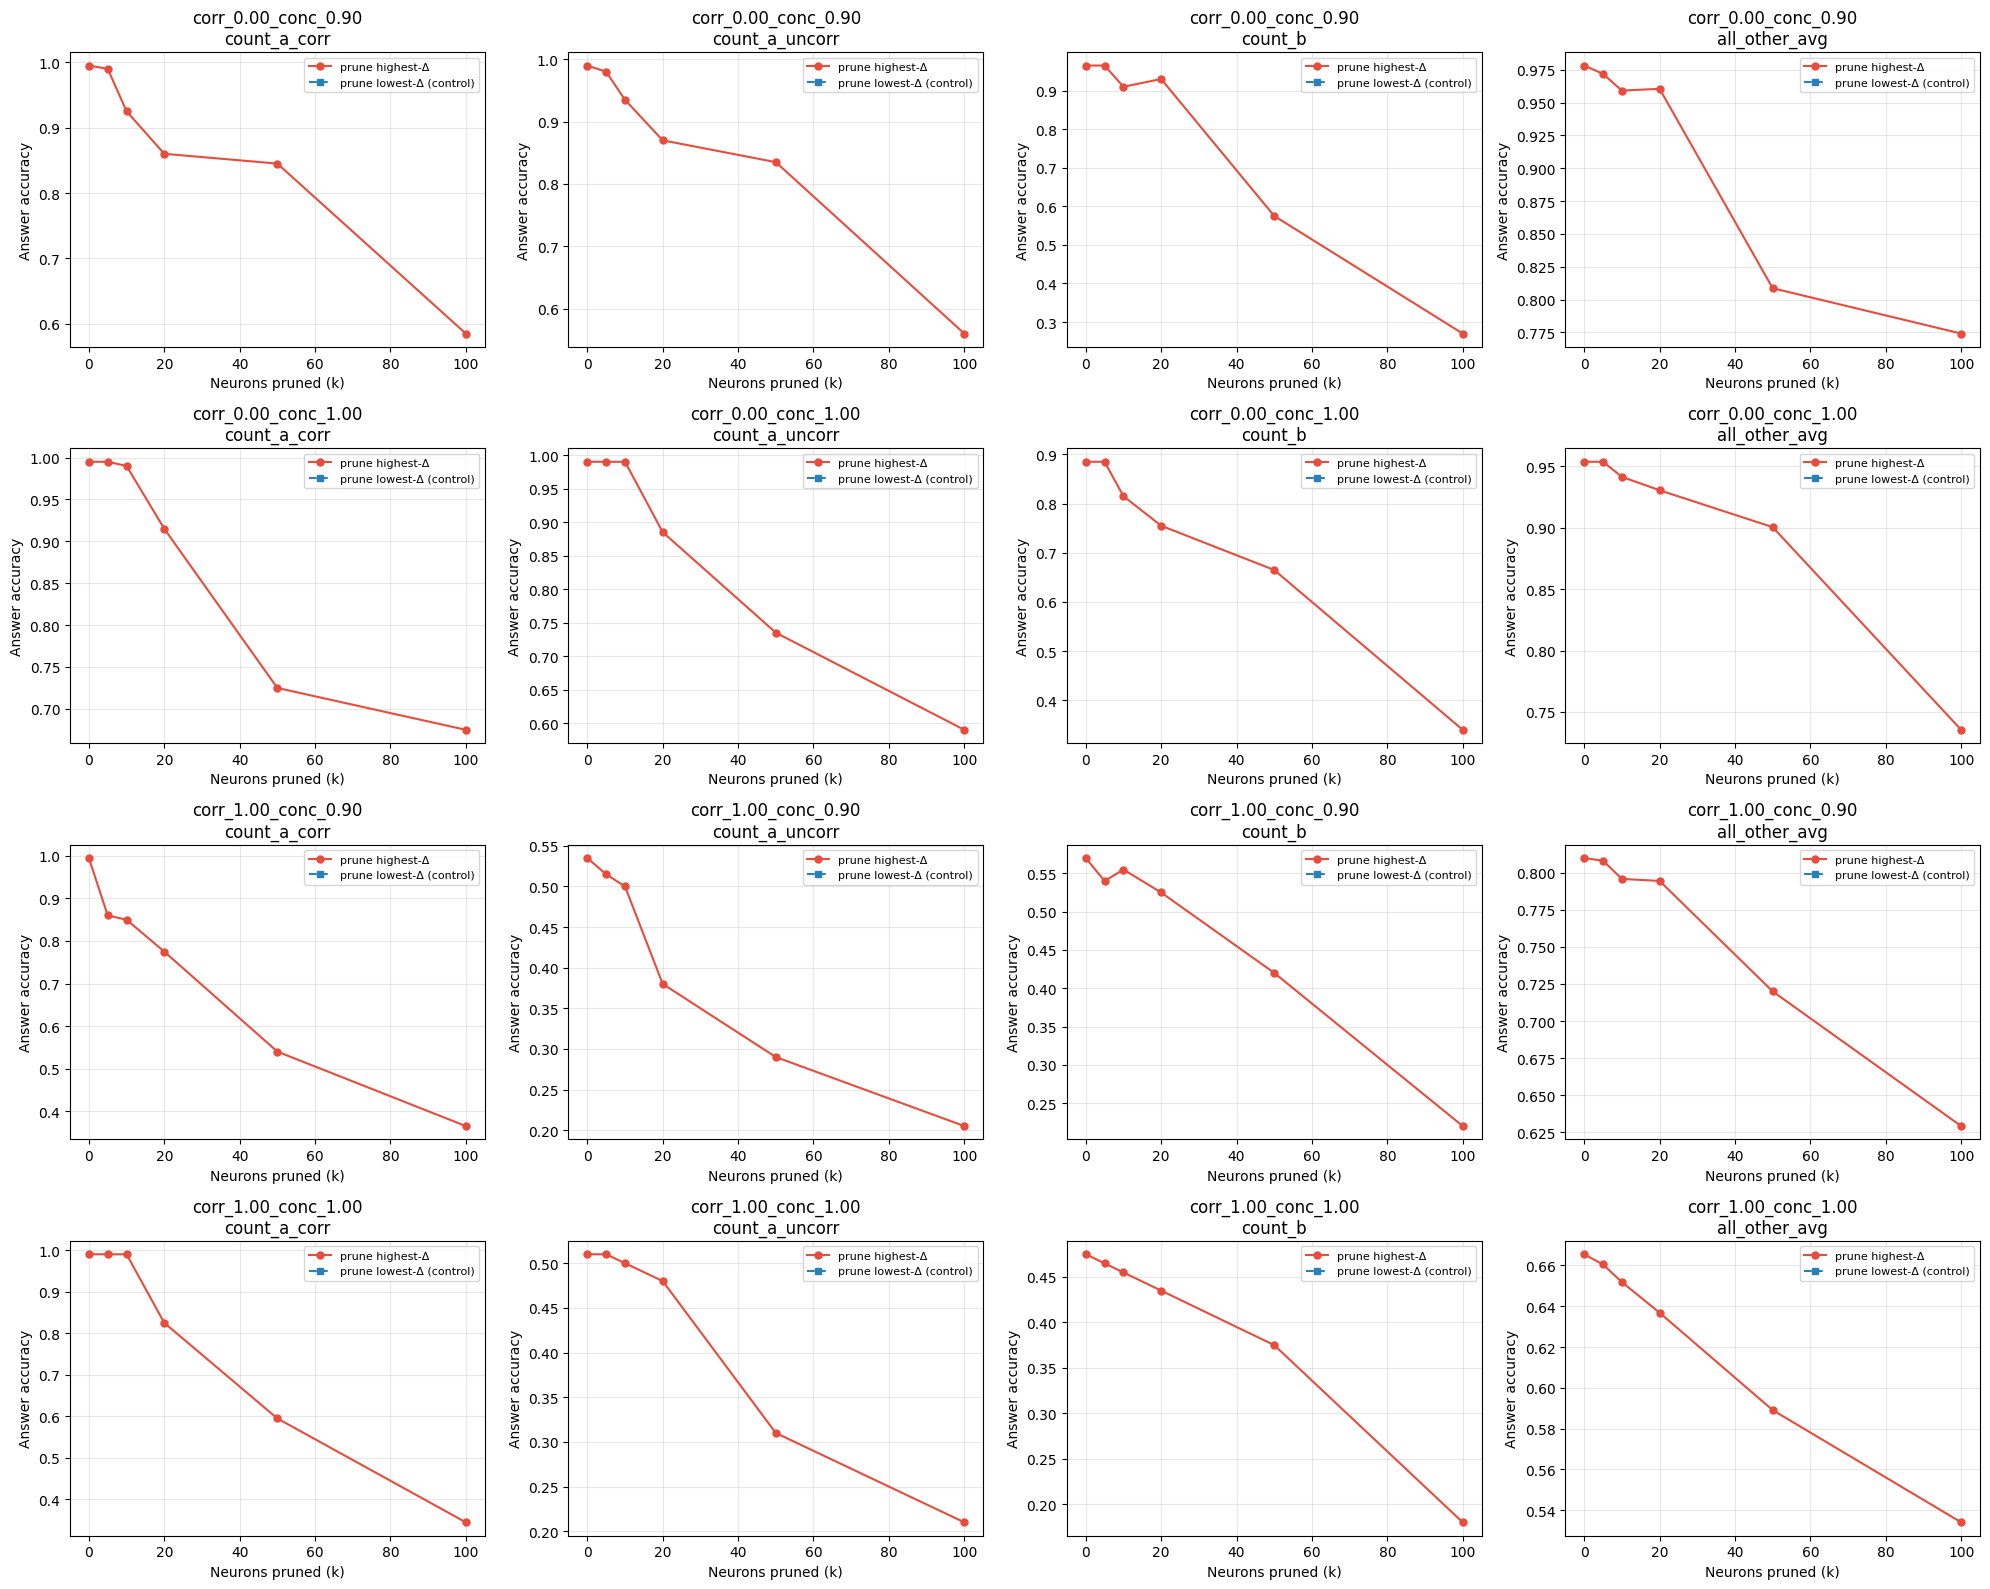

In [26]:
fig, axes = plt.subplots(len(model_pairs), len(VAL_SPLITS),
                         figsize=(5*len(VAL_SPLITS), 4*len(model_pairs)), sharey=False)
if len(model_pairs) == 1:
    axes = axes[np.newaxis, :]

for row, (pair_name, res) in enumerate(sorted(pruning_results.items())):
    for col, split in enumerate(VAL_SPLITS):
        ax = axes[row, col]
        for strategy, color, ls in [('top', '#e74c3c', '-o'), ('bottom', '#2980b9', '--s')]:
            ks   = sorted(res[strategy].keys())
            accs = [res[strategy][k][split]['acc'] for k in ks]
            label = 'prune highest-Δ' if strategy == 'top' else 'prune lowest-Δ (control)'
            ax.plot(ks, accs, ls, color=color, label=label, markersize=5)
        ax.set_title(f'{pair_name}\n{split}')
        ax.set_xlabel('Neurons pruned (k)')
        ax.set_ylabel('Answer accuracy')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/workspace/PCFG/results/pruning_experiment.png', dpi=150)
plt.show()


In [45]:
rows = []
for pair_name, res in sorted(pruning_results.items()):
    for strategy in ['top', 'bottom']:
        for k in K_VALUES:
            row = {'pair': pair_name, 'strategy': strategy, 'k': k,
                   'pct_pruned': f"{100*k/4608:.1f}%"}
            for split in VAL_SPLITS:
                row[f'{split}_acc'] = res[strategy][k][split]['acc']
            rows.append(row)

df_prune = pd.DataFrame(rows)
# Show just top-delta results for conciseness
display(df_prune[df_prune.strategy == 'top']
        .set_index(['pair', 'k'])
        .drop(columns='strategy')
        .style.background_gradient(cmap='RdYlGn', axis=0, subset=[c for c in df_prune.columns if '_acc' in c])
        .format({'pct_pruned': '{}', **{c: '{:.3f}' for c in df_prune.columns if '_acc' in c}})
)


KeyError: 0